# Section 1: Fine-Mapping for xQTL and GWAS

This notebook documents our fine-mapping results from all analyzed contexts.

The steps are:

1. Load the flattened table containing QTL data that show signals with AD.
2. Plot the union of credible set (CS) regions for each context.
3. Plot the posterior inclusion probability (PIP) of CS for each context.

From this notebook, you will obtain two outputs:
1. A subset of the flattened table that can be used in Section 10(`Fungen_xQTL_allQTL.overlapped.gwas.export.BIN1.rds`). However, this is optional, as another option to reload data from the original flattened table is provided in Section 10.
2. The relevant contexts showing signals from fine-mapping results(`BIN1_finemapping_contexts.rds`), which serve as input for Section 7.

#### - Flatten table
- This resource enables us to swiftly access our whole-genome univariate fine-mapping results and assess potential shared signals with AD GWAS.

In [1]:
library(BEDMatrix)

In [2]:
source('../../codes/utilis.R')
source('../../codes/qtl_utils.R')
gene_name = 'BIN1'
tar_gene_info <- get_gene_info(gene_name = gene_name)
gene_id <- tar_gene_info$gene_info$region_id

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors



Attaching package: ‘data.table’




The following objects are masked from ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year




The following objects are masked from ‘package:dplyr’:

    between, first, last




The following object is masked from ‘package:purrr’:

    transpose





Attaching package: ‘cowplot’




The following object is masked from ‘package:lubridate’:

    stamp




The most updated version of flatten table is `s3://statfungen/ftp_fgc_xqtl/interactive_analysis/aw3600/case_example_codes/all_top_loci_except_fsusie_snATAC_multigene.rds`

In [3]:
# read flatten table
fla_tb <- readRDS('/data/interactive_analysis/aw3600/case_example_codes/all_top_loci_except_fsusie_snATAC_multigene.rds')

In [4]:
head(fla_tb)

#chr,start,end,a1,a2,variant_ID,gene_ID,event_ID,cs_coverage_0.95,cs_coverage_0.7,cs_coverage_0.5,PIP,conditional_effect,context,resource,lfsr,z
<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>
1,903284,903285,C,T,chr1:903285:T:C,ENSG00000235169,Knight_eQTL_brain_ENSG00000235169,0,0,0,0.04257485,-0.842082669467583,Knight_eQTL_brain,single_context,NA,NA
1,903351,903352,A,G,chr1:903352:G:A,ENSG00000235169,Knight_eQTL_brain_ENSG00000235169,0,0,0,0.04257485,-0.842082669467583,Knight_eQTL_brain,single_context,NA,NA
1,903509,903510,G,A,chr1:903510:A:G,ENSG00000235169,Knight_eQTL_brain_ENSG00000235169,0,0,0,0.04257485,-0.842082669467583,Knight_eQTL_brain,single_context,NA,NA
1,903535,903536,T,A,chr1:903536:A:T,ENSG00000235169,Knight_eQTL_brain_ENSG00000235169,0,0,0,0.04257485,-0.842082669467583,Knight_eQTL_brain,single_context,NA,NA
1,904080,904081,C,T,chr1:904081:T:C,ENSG00000235169,Knight_eQTL_brain_ENSG00000235169,0,0,0,0.04257485,-0.842082669467583,Knight_eQTL_brain,single_context,NA,NA
1,904114,904115,T,G,chr1:904115:G:T,ENSG00000235169,Knight_eQTL_brain_ENSG00000235169,0,0,0,0.04257485,-0.842082669467583,Knight_eQTL_brain,single_context,NA,NA


In [5]:
### Hao: This will retain all the rows that are variants from the eQTL of the said gene
library(dplyr)
fla_tb_extracted  = fla_tb%>%group_by(variant_ID)%>%filter(any(gene_ID == gene_id)) %>% filter(resource%in%c("single_context","AD_GWAS"))
### Hao: save also the variants that eQTL of the gene but not AD. It is still small enough
fla_tb_extracted %>%ungroup%>% saveRDS(., paste0('Fungen_xQTL_allQTL.overlapped.gwas.export.',gene_name,'.rds'))

In [6]:
fla_tb_extracted

#chr,start,end,a1,a2,variant_ID,gene_ID,event_ID,cs_coverage_0.95,cs_coverage_0.7,cs_coverage_0.5,PIP,conditional_effect,context,resource,lfsr,z
<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>
2,127029679,127029680,G,A,chr2:127029680:A:G,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,2,2,2,0.29166606,-0.807067540339813,STARNET_eQTL_Mac,single_context,NA,NA
2,127038393,127038394,A,G,chr2:127038394:G:A,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,2,2,2,0.29166606,-0.807067540339813,STARNET_eQTL_Mac,single_context,NA,NA
2,127057057,127057058,T,G,chr2:127057058:G:T,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,2,2,0,0.29166606,-0.807067540339813,STARNET_eQTL_Mac,single_context,NA,NA
2,127074234,127074235,C,T,chr2:127074235:T:C,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,1,1,1,0.02916705,0.661035115045875,STARNET_eQTL_Mac,single_context,NA,NA
2,127074768,127074769,T,C,chr2:127074769:C:T,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,1,1,1,0.02916705,0.661035115045875,STARNET_eQTL_Mac,single_context,NA,NA
2,127074771,127074772,A,G,chr2:127074772:G:A,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,1,1,1,0.02916705,0.661035115045875,STARNET_eQTL_Mac,single_context,NA,NA
2,127074846,127074847,A,C,chr2:127074847:C:A,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,1,1,1,0.02916705,0.661035115045875,STARNET_eQTL_Mac,single_context,NA,NA
2,127074850,127074851,T,C,chr2:127074851:C:T,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,1,1,1,0.02916705,0.661035115045875,STARNET_eQTL_Mac,single_context,NA,NA
2,127075107,127075108,G,T,chr2:127075108:T:G,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,1,1,1,0.02916705,0.661035115045875,STARNET_eQTL_Mac,single_context,NA,NA


## plot the region including all variants in top loci table even outside  CS

In [7]:
fla_tb_all <- fla_tb_extracted
fla_tb_ad <- fla_tb_all %>% filter(resource == "AD_GWAS")

In [8]:
# pull BIN1 flaten table
BIN1 <- fla_tb_all %>% filter(gene_ID == gene_id)

In [9]:
# as we have know BIN1 have Mic specific signal, so we want to check MiGA cohort for validation
# separate BIN1 flaten table into MiGA data and not MiGA data
BIN1_MiGA <- BIN1 %>% filter(str_detect(context, 'MiGA'))
BIN1_notMiGA <- BIN1 %>% filter(!str_detect(context, 'MiGA') & !str_detect(context, 'PSI') & !str_detect(context, 'sQTL')) 

In [10]:
# prepare for plot df
# BIN1_MiGA_df <- BIN1_MiGA %>% select(variant_id, study) %>% mutate(context = 'MiGA')
# BIN1_notMiGA_df <- BIN1_notMiGA %>% select(variant_id, study)  %>% mutate(context = 'notMiGA')
BIN1_df <- data.frame()
BIN1_MiGA_df <- BIN1_MiGA  %>% mutate(classify = 'MiGA')
BIN1_notMiGA_df <- BIN1_notMiGA%>% mutate(classify = 'notMiGA')
BIN1_df <- rbind(BIN1_MiGA_df, BIN1_notMiGA_df)
# Create a list of new dataframes for each AD_cohort
ad_rows <- lapply(unique(fla_tb_ad$context), function(AD_cohort) {
  BIN1_df %>%
    filter(variant_ID %in% (fla_tb_ad %>% filter(context == AD_cohort) %>% pull(variant_ID))) %>%
    mutate(context = AD_cohort, classify = "AD")
})
BIN1_df <- rbind(BIN1_df, do.call(bind_rows,ad_rows))

In [11]:
BIN1_df %>% head(n=2)
BIN1_df$cs_coverage_0.95 <- as.factor(BIN1_df$cs_coverage_0.95)
BIN1_df$context <- as.factor(BIN1_df$context)

#chr,start,end,a1,a2,variant_ID,gene_ID,event_ID,cs_coverage_0.95,cs_coverage_0.7,cs_coverage_0.5,PIP,conditional_effect,context,resource,lfsr,z,classify
<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
2,124569059,124569060,A,T,chr2:124569060:T:A,ENSG00000136717,MiGA_THA_eQTL_ENSG00000136717,0,0,0,0.05621847,-0.134711919941607,MiGA_THA_eQTL,single_context,NA,NA,MiGA
2,124756525,124756526,G,A,chr2:124756526:A:G,ENSG00000136717,MiGA_GTS_eQTL_ENSG00000136717,0,0,0,0.03611385,-0.181682045922086,MiGA_GTS_eQTL,single_context,NA,NA,MiGA


In [12]:
classifies <- BIN1_df$classify %>% unique
classifies

[1] "MiGA"    "notMiGA" "AD"

In [13]:
# Define context levels with AD at the top (if present)
classifies <- BIN1_df$classify %>% unique
context_levels <- if ("AD" %in% classifies) {
  c("AD", setdiff(classifies, "AD"))  # AD comes first, followed by the rest
} else {
  classifies  # Use original order if AD isn't present
}
# Option 1: Order by a specific column (if needed)
BIN1_df <- BIN1_df[order(BIN1_df$classify), ]  # Optional if ordering is required

# Set 'study' as a factor following the ordered appearance
BIN1_df$context <- factor(BIN1_df$context, levels = unique(BIN1_df$context))

In [14]:
options(repr.plot.width=12, repr.plot.height= 0.8 * (BIN1_df$context %>% unique %>% length))
region_p_all <- ggplot(data = BIN1_df, aes(x = end, y = context, color = classify)) + 
  geom_line(size = 3) +   
  geom_point(size = 2, alpha = 0.5) + # Add points to help see the data
  labs (x = "position",color = "Category") +
  theme_minimal(base_size = 14) +
  theme(text = element_text(size = 14),   # Increase general text size
        axis.title = element_text(size = 16, face = "bold"),# Increase axis title size
        legend.title = element_text(size = 16, face = "bold"),
        legend.text = element_text(size = 14),
        axis.text = element_text(size = 10),   # Increase general axis text size
        axis.text.y = element_text(size = 14),
        plot.title = element_text(face = "bold", hjust = 0.5,size = 18)) + # Increase y-axis text size specifically
  scale_y_discrete(limits = rev(levels(BIN1_df$context)))  + ggtitle(gene_name)
dir.create(paste0('plots/',gene_name), recursive = T) 
ggsave(paste0('plots/',gene_name,'/sec1.uni_fmp_region_all.pdf'), width = 10, height = 0.8 * (BIN1_df$context %>% unique %>% length))


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


Warning message in dir.create(paste0("plots/", gene_name), recursive = T):
“'plots/BIN1' already exists”


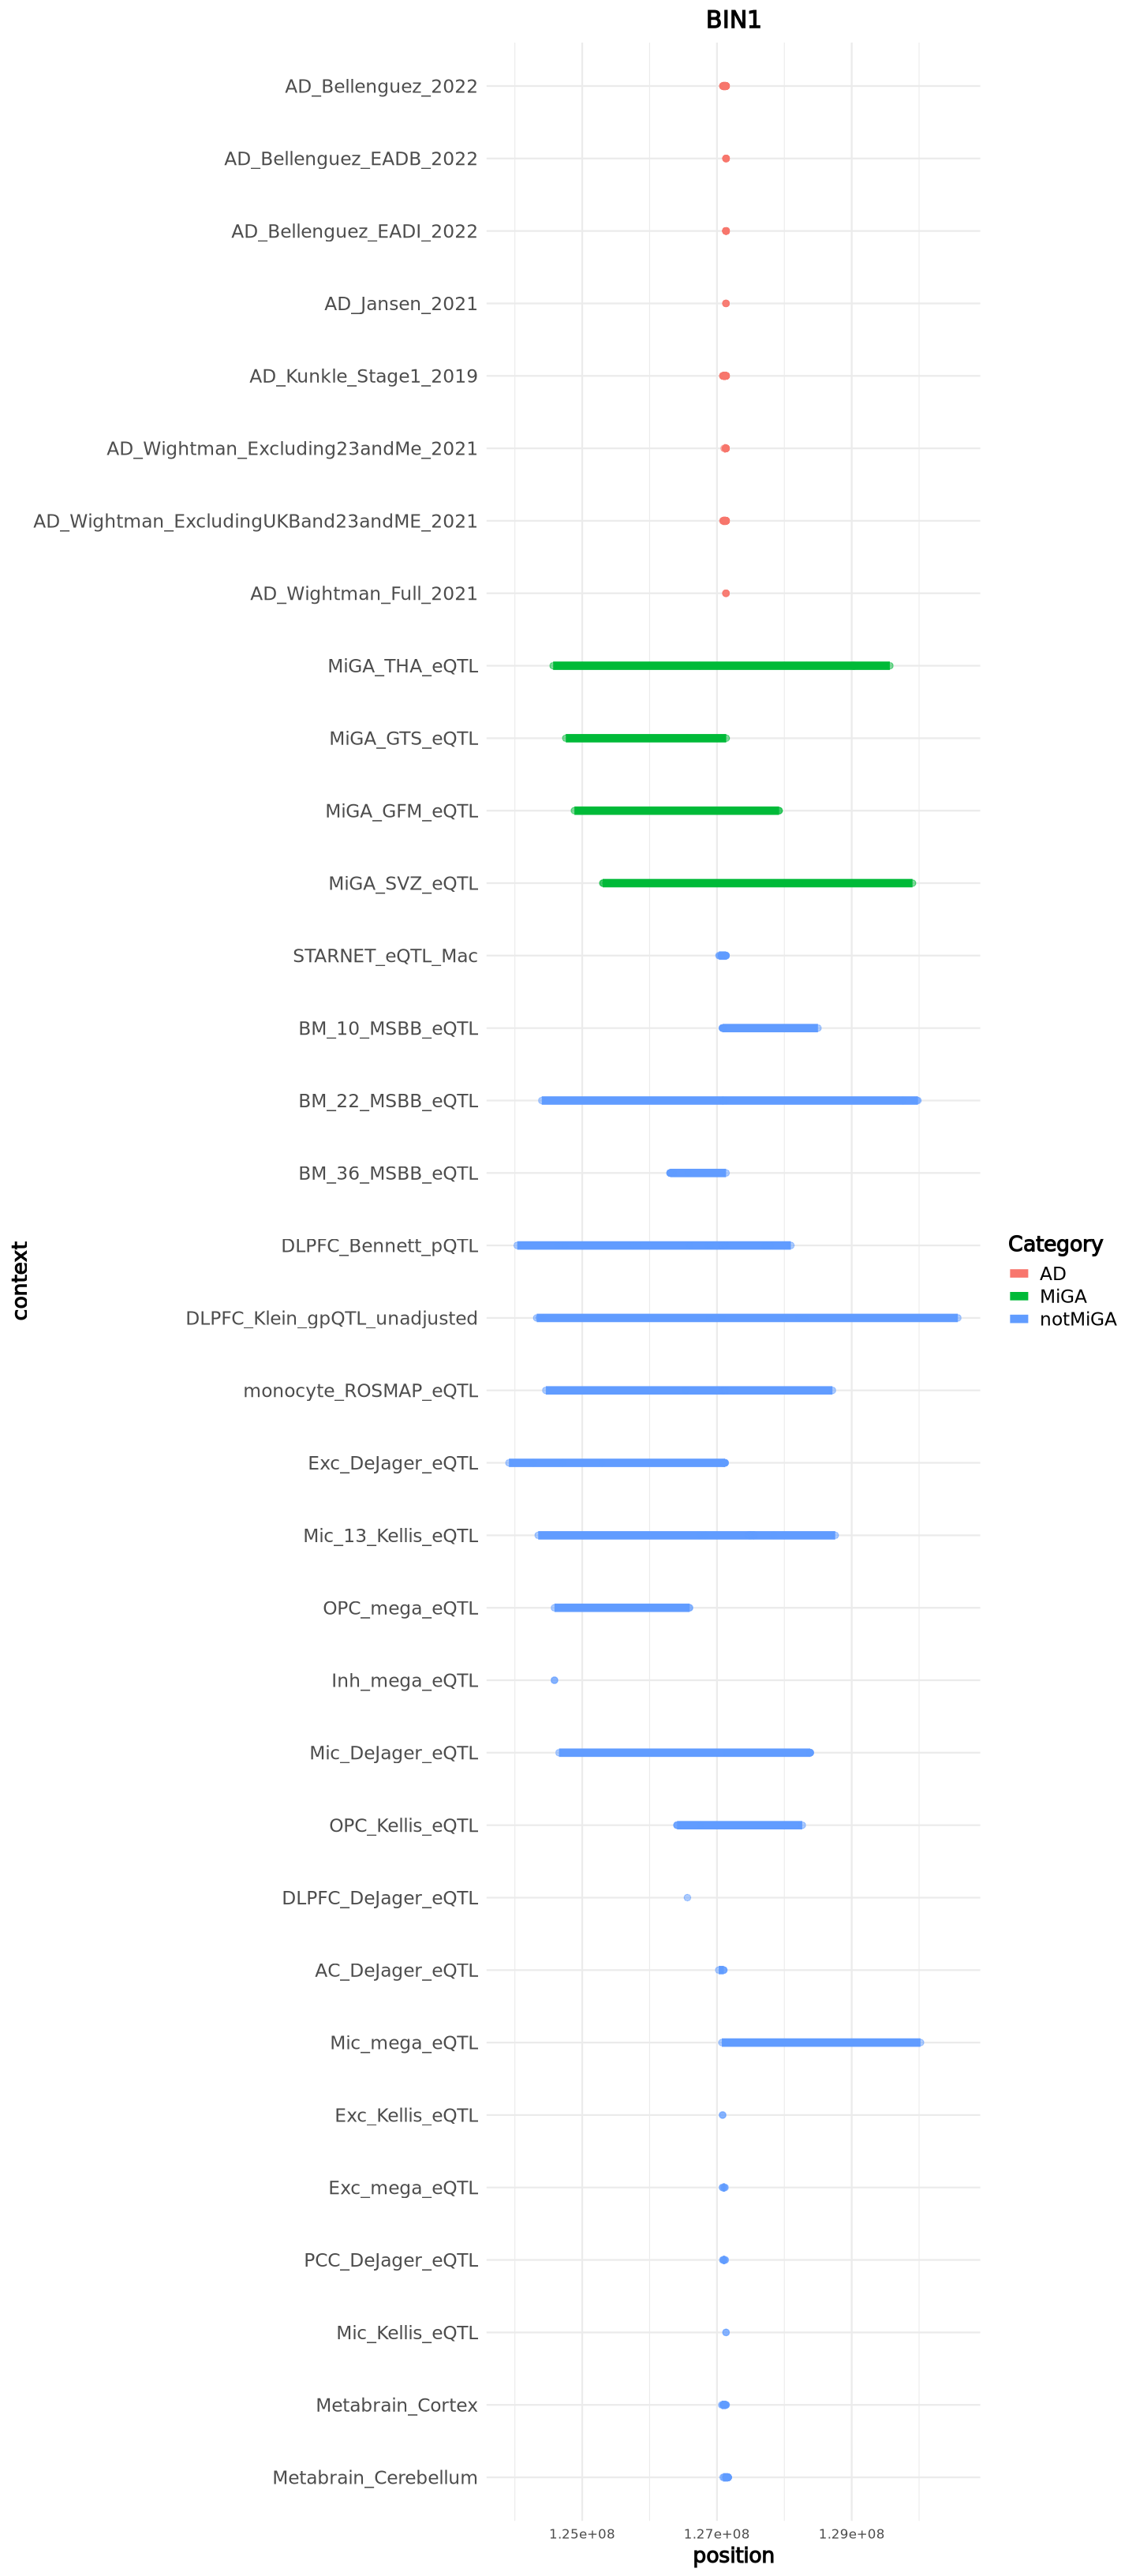

In [15]:
region_p_all

In [16]:
## plot the region in CS only

In [17]:
# pull flaten table have cs results
library(dplyr)
fla_tb_extracted_cs <- fla_tb_all %>% filter((cs_coverage_0.95 > 0 | cs_coverage_0.7 > 0| cs_coverage_0.5 > 0)) %>% 
            mutate(cs_id  =  ifelse(cs_coverage_0.95 !=0 , paste('cs95', cs_coverage_0.95, sep = '_'), 
                                                 ifelse(cs_coverage_0.7 !=0 , paste('cs70', cs_coverage_0.7, sep = '_'), paste('cs50', cs_coverage_0.5, sep = '_') )))

In [18]:
head(fla_tb_extracted_cs)

#chr,start,end,a1,a2,variant_ID,gene_ID,event_ID,cs_coverage_0.95,cs_coverage_0.7,cs_coverage_0.5,PIP,conditional_effect,context,resource,lfsr,z,cs_id
<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
2,127029679,127029680,G,A,chr2:127029680:A:G,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,2,2,2,0.29166606,-0.807067540339813,STARNET_eQTL_Mac,single_context,NA,NA,cs95_2
2,127038393,127038394,A,G,chr2:127038394:G:A,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,2,2,2,0.29166606,-0.807067540339813,STARNET_eQTL_Mac,single_context,NA,NA,cs95_2
2,127057057,127057058,T,G,chr2:127057058:G:T,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,2,2,0,0.29166606,-0.807067540339813,STARNET_eQTL_Mac,single_context,NA,NA,cs95_2
2,127074234,127074235,C,T,chr2:127074235:T:C,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,1,1,1,0.02916705,0.661035115045875,STARNET_eQTL_Mac,single_context,NA,NA,cs95_1
2,127074768,127074769,T,C,chr2:127074769:C:T,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,1,1,1,0.02916705,0.661035115045875,STARNET_eQTL_Mac,single_context,NA,NA,cs95_1
2,127074771,127074772,A,G,chr2:127074772:G:A,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,1,1,1,0.02916705,0.661035115045875,STARNET_eQTL_Mac,single_context,NA,NA,cs95_1


In [19]:
# pull AD flaten table
fla_tb_ad_cs <- fla_tb_extracted_cs %>% filter(resource == "AD_GWAS")
fla_tb_ad_cs %>% head(n=2)

#chr,start,end,a1,a2,variant_ID,gene_ID,event_ID,cs_coverage_0.95,cs_coverage_0.7,cs_coverage_0.5,PIP,conditional_effect,context,resource,lfsr,z,cs_id
<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
2,127135233,127135234,T,C,chr2:127135234:C:T,chr2_125689597_127728648,AD_Bellenguez_2022,1,1,1,1.0000000,NA,AD_Bellenguez_2022,AD_GWAS,NA,20.07143,cs95_1
2,127135233,127135234,T,C,chr2:127135234:C:T,chr2_125689597_127728648,AD_Bellenguez_EADB_2022,1,1,1,0.9996894,NA,AD_Bellenguez_EADB_2022,AD_GWAS,NA,13.21241,cs95_1


In [20]:
# pull BIN1 flaten table
BIN1 <- fla_tb_extracted_cs %>% filter(gene_ID == gene_id)

In [21]:
head(BIN1)

#chr,start,end,a1,a2,variant_ID,gene_ID,event_ID,cs_coverage_0.95,cs_coverage_0.7,cs_coverage_0.5,PIP,conditional_effect,context,resource,lfsr,z,cs_id
<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
2,127029679,127029680,G,A,chr2:127029680:A:G,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,2,2,2,0.29166606,-0.807067540339813,STARNET_eQTL_Mac,single_context,NA,NA,cs95_2
2,127038393,127038394,A,G,chr2:127038394:G:A,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,2,2,2,0.29166606,-0.807067540339813,STARNET_eQTL_Mac,single_context,NA,NA,cs95_2
2,127057057,127057058,T,G,chr2:127057058:G:T,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,2,2,0,0.29166606,-0.807067540339813,STARNET_eQTL_Mac,single_context,NA,NA,cs95_2
2,127074234,127074235,C,T,chr2:127074235:T:C,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,1,1,1,0.02916705,0.661035115045875,STARNET_eQTL_Mac,single_context,NA,NA,cs95_1
2,127074768,127074769,T,C,chr2:127074769:C:T,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,1,1,1,0.02916705,0.661035115045875,STARNET_eQTL_Mac,single_context,NA,NA,cs95_1
2,127074771,127074772,A,G,chr2:127074772:G:A,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,1,1,1,0.02916705,0.661035115045875,STARNET_eQTL_Mac,single_context,NA,NA,cs95_1


In [22]:
# check if this gene has Mi
fla_tb_ad_cs %>% filter(variant_ID %in% (BIN1 %>% filter(str_detect(context, 'MiGA')) %>% pull(variant_ID)))

#chr,start,end,a1,a2,variant_ID,gene_ID,event_ID,cs_coverage_0.95,cs_coverage_0.7,cs_coverage_0.5,PIP,conditional_effect,context,resource,lfsr,z,cs_id
<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>


In [23]:
# as we have know BIN1 have Mic specific signal, so we want to check MiGA cohort for validation
# separate BIN1 flaten table into MiGA data and not MiGA data
BIN1_MiGA <- BIN1 %>% filter(str_detect(context, 'MiGA'))
BIN1_notMiGA <- BIN1 %>% filter(!str_detect(context, 'MiGA') & !str_detect(context, 'PSI') & !str_detect(context, 'sQTL')) 

In [24]:
# prepare for plot df
# BIN1_MiGA_df <- BIN1_MiGA %>% select(variant_id, study) %>% mutate(context = 'MiGA')
# BIN1_notMiGA_df <- BIN1_notMiGA %>% select(variant_id, study)  %>% mutate(context = 'notMiGA')
BIN1_df <- data.frame()
BIN1_MiGA_df <- BIN1_MiGA  %>% mutate(classify = 'MiGA')
BIN1_notMiGA_df <- BIN1_notMiGA%>% mutate(classify = 'notMiGA')
BIN1_df <- rbind(BIN1_MiGA_df, BIN1_notMiGA_df)
# Create a list of new dataframes for each AD_cohort
ad_rows <- lapply(unique(fla_tb_ad_cs$context), function(AD_cohort) {
  BIN1_df %>%
    filter(variant_ID %in% (fla_tb_ad_cs %>% filter(context == AD_cohort) %>% pull(variant_ID))) %>%
    mutate(context = AD_cohort, classify = "AD")
})
BIN1_df <- rbind(BIN1_df, do.call(bind_rows,ad_rows))

In [25]:
BIN1_df %>% head(n=2)
BIN1_df$cs_coverage_0.95 <- as.factor(BIN1_df$cs_coverage_0.95)
BIN1_df$context <- as.factor(BIN1_df$context)

#chr,start,end,a1,a2,variant_ID,gene_ID,event_ID,cs_coverage_0.95,cs_coverage_0.7,cs_coverage_0.5,PIP,conditional_effect,context,resource,lfsr,z,cs_id,classify
<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>
2,127029679,127029680,G,A,chr2:127029680:A:G,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,2,2,2,0.2916661,-0.807067540339813,STARNET_eQTL_Mac,single_context,NA,NA,cs95_2,notMiGA
2,127038393,127038394,A,G,chr2:127038394:G:A,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,2,2,2,0.2916661,-0.807067540339813,STARNET_eQTL_Mac,single_context,NA,NA,cs95_2,notMiGA


In [26]:
BIN1_df %>% head

#chr,start,end,a1,a2,variant_ID,gene_ID,event_ID,cs_coverage_0.95,cs_coverage_0.7,cs_coverage_0.5,PIP,conditional_effect,context,resource,lfsr,z,cs_id,classify
<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<int>,<int>,<dbl>,<chr>,<fct>,<chr>,<chr>,<dbl>,<chr>,<chr>
2,127029679,127029680,G,A,chr2:127029680:A:G,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,2,2,2,0.29166606,-0.807067540339813,STARNET_eQTL_Mac,single_context,NA,NA,cs95_2,notMiGA
2,127038393,127038394,A,G,chr2:127038394:G:A,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,2,2,2,0.29166606,-0.807067540339813,STARNET_eQTL_Mac,single_context,NA,NA,cs95_2,notMiGA
2,127057057,127057058,T,G,chr2:127057058:G:T,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,2,2,0,0.29166606,-0.807067540339813,STARNET_eQTL_Mac,single_context,NA,NA,cs95_2,notMiGA
2,127074234,127074235,C,T,chr2:127074235:T:C,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,1,1,1,0.02916705,0.661035115045875,STARNET_eQTL_Mac,single_context,NA,NA,cs95_1,notMiGA
2,127074768,127074769,T,C,chr2:127074769:C:T,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,1,1,1,0.02916705,0.661035115045875,STARNET_eQTL_Mac,single_context,NA,NA,cs95_1,notMiGA
2,127074771,127074772,A,G,chr2:127074772:G:A,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,1,1,1,0.02916705,0.661035115045875,STARNET_eQTL_Mac,single_context,NA,NA,cs95_1,notMiGA


In [27]:
# Define context levels with AD at the top (if present)
classifies <- BIN1_df$classify %>% unique
context_levels <- if ("AD" %in% classifies) {
  c("AD", setdiff(classifies, "AD"))  # AD comes first, followed by the rest
} else {
  classifies  # Use original order if AD isn't present
}
# Option 1: Order by a specific column (if needed)
BIN1_df <- BIN1_df[order(BIN1_df$classify), ]  # Optional if ordering is required

# Set 'study' as a factor following the ordered appearance
BIN1_df$context <- factor(BIN1_df$context, levels = unique(BIN1_df$context))

In [28]:
options(repr.plot.width=12, repr.plot.height= 0.8 * (BIN1_df$context %>% unique %>% length))
region_p <- ggplot(data = BIN1_df, aes(x = end, y = context, color = classify)) + 
  geom_line(size = 3) +   
  geom_point(size = 2, alpha = 0.5) +  # Add points to help see the data
  labs (x = "position",color = "Category") +
  theme_minimal(base_size = 14) +
  theme(text = element_text(size = 14),   # Increase general text size
        axis.title = element_text(size = 16, face = "bold"),# Increase axis title size
        legend.title = element_text(size = 16, face = "bold"),
        legend.text = element_text(size = 14),
        axis.text = element_text(size = 10),   # Increase general axis text size
        axis.text.y = element_text(size = 14),
        plot.title = element_text(face = "bold", hjust = 0.5,size = 18)) + # Increase y-axis text size specifically
  scale_y_discrete(limits = rev(levels(BIN1_df$context)))  + ggtitle(gene_name)
dir.create(paste0('plots/',gene_name), recursive = T) 
ggsave(paste0('plots/',gene_name,'/sec1.uni_fmp_region.pdf'), width = 10, height = 0.8 * (BIN1_df$context %>% unique %>% length))


Warning message in dir.create(paste0("plots/", gene_name), recursive = T):
“'plots/BIN1' already exists”


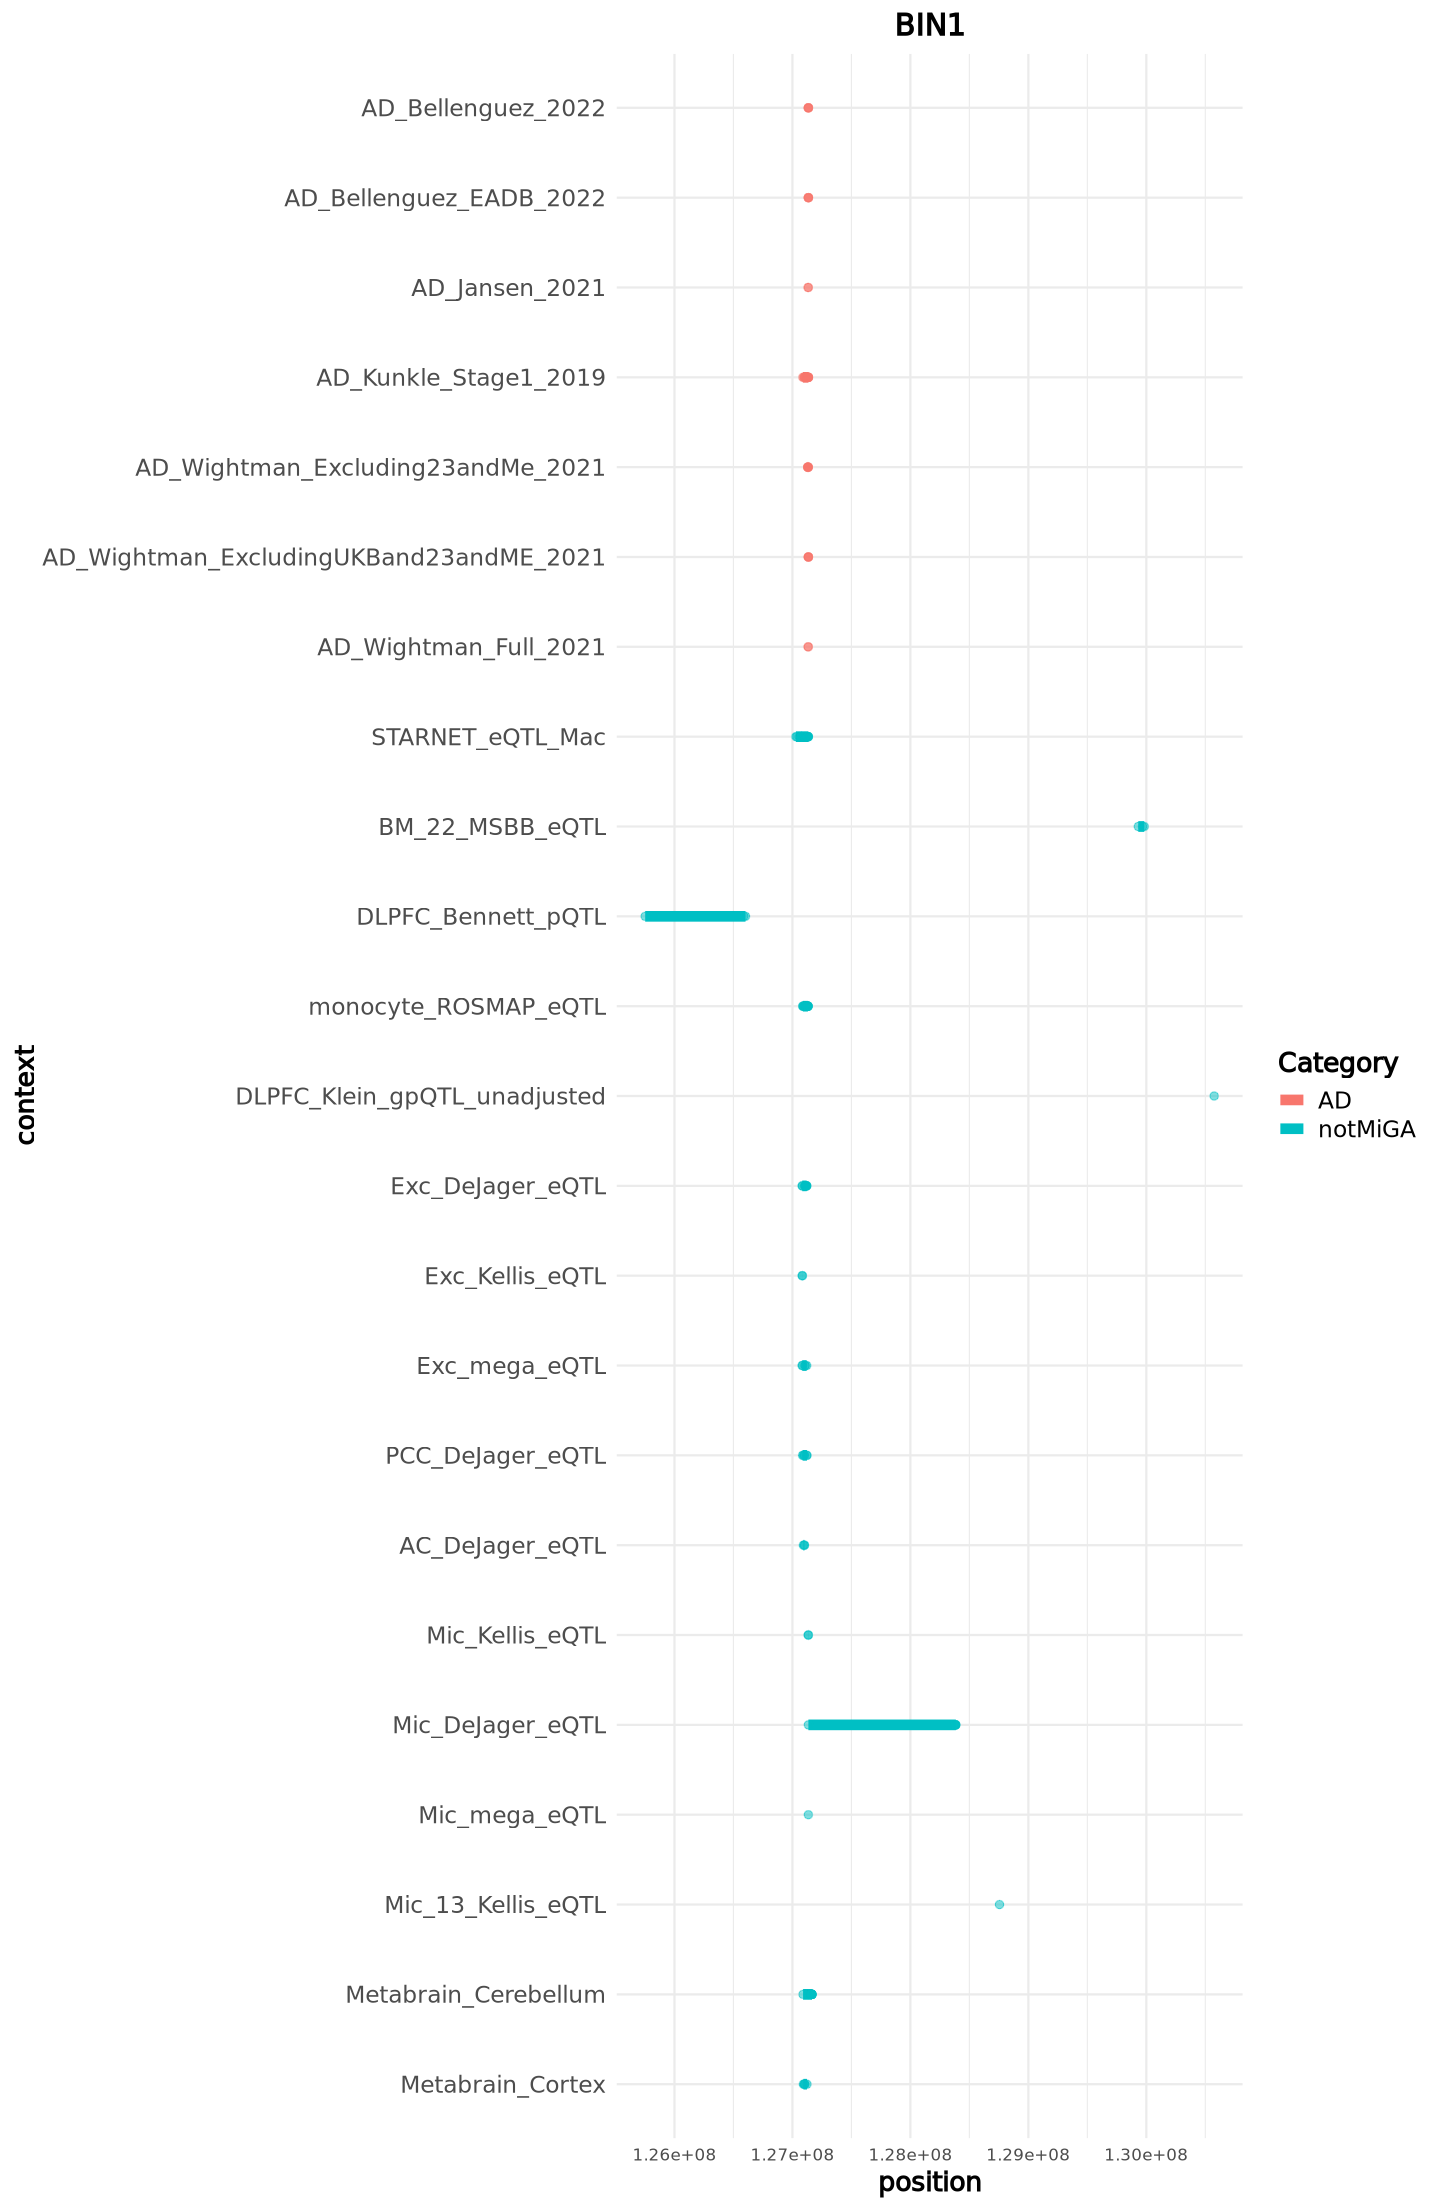

In [29]:
region_p

## plot the pip in CS only

In [30]:
cs_levels <- c(BIN1_df$cs_id[str_detect(BIN1_df$cs_id, 'cs95')], BIN1_df$cs_id[str_detect(BIN1_df$cs_id, 'cs70')], BIN1_df$cs_id[str_detect(BIN1_df$cs_id, 'cs50')]) %>% unique
BIN1_df$cs_id <- factor(BIN1_df$cs_id, levels = cs_levels)
options(repr.plot.width=8, repr.plot.height= 1.1 * (BIN1_df$context %>% unique %>% length))

In [31]:
num_colors_needed <- length(unique(BIN1_df$cs_id))
colors <- hcl(h = seq(15, 375, length = num_colors_needed + 1), 
              c = 100, l = 65)[1:num_colors_needed]

pip_p <- ggplot(BIN1_df, aes(x = end, y = PIP, color = cs_id)) +
  geom_point(size = 3, alpha = 0.7) +  # 
  labs(x = "Variant Position", y = "PIP", color = "CS id") +  # 
  theme_minimal(base_size = 14) + 
  theme(
        text = element_text(size = 14),   # Increase general text size
        axis.title = element_text(size = 16, face = "bold"),# Increase axis title size
        legend.title = element_text(size = 16, face = "bold"),
        legend.text = element_text(size = 14),
        axis.text = element_text(size = 10),   # Increase general axis text size
        plot.title = element_text(face = "bold", hjust = 0.5,size = 18),
        panel.background = element_blank(),  # 
        panel.grid.major = element_line(color = "grey80"),  # 
        legend.position = "bottom") +  # 
  facet_wrap(~ context, ncol = 1) +  # 
  scale_color_manual(values = colors) +  # 
  scale_x_continuous(labels = scales::comma) +  
  ggtitle(gene_name)  
ggsave(paste0('plots/',gene_name,'/sec1.uni_fmp_pip.pdf'), width = 8, height = 1.1 * (BIN1_df$context %>% unique %>% length))

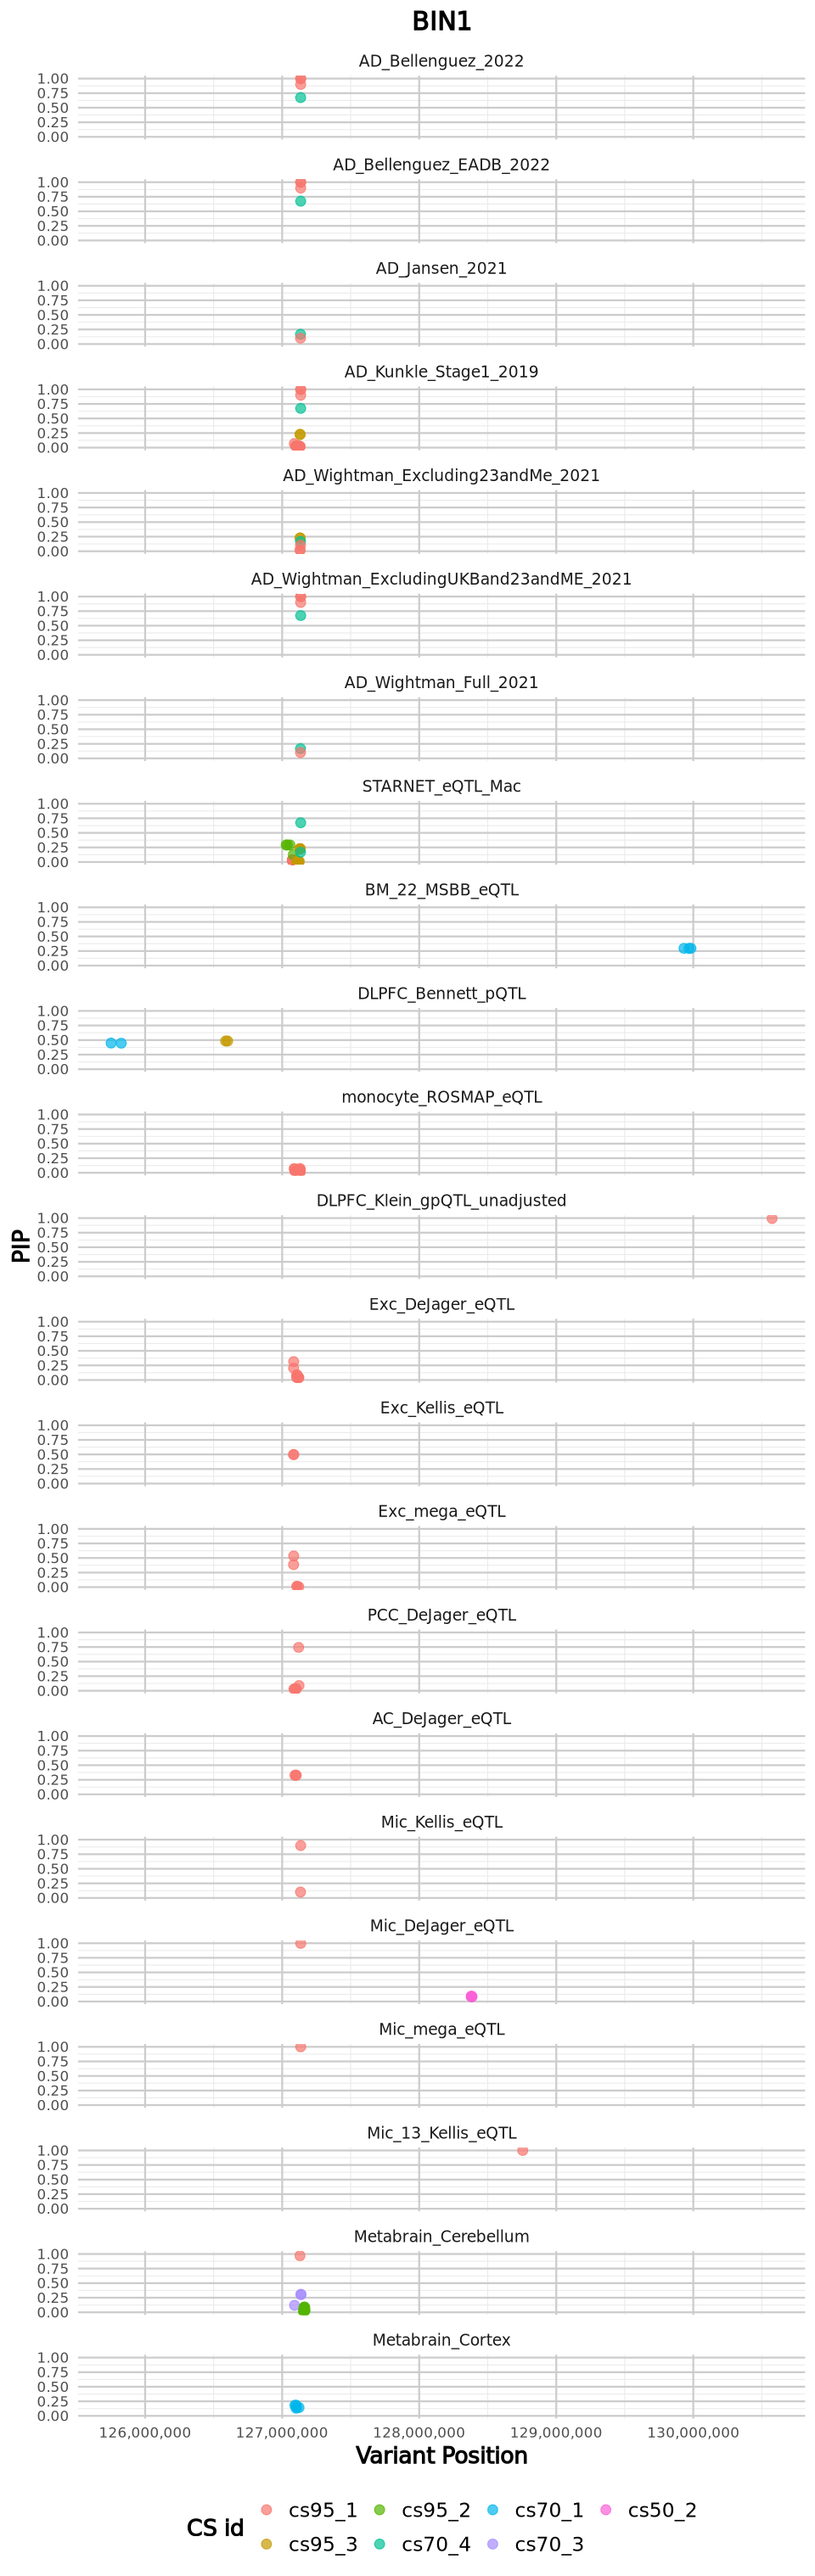

In [32]:
pip_p

In [33]:
# do not save metabrain for now, this would be loaded to section 8
# metabrain has not been merged to exported sumstats file
BIN1_df %>% pull(context) %>% unique %>% .[!str_detect(., 'Metabrain')] %>% saveRDS(paste0(gene_name, '_finemapping_contexts.rds'))

#### - Optional: Univariate fine mapping analysis
- The exported data underwent some postprocessing; therefore, you might also want to review the raw univariate fine-mapping results.    

The univariate fine mapping results for raw data in flatten table is 
`s3://statfungen/ftp_fgc_xqtl/analysis_result/finemapping_twas/susie_twas/` or you can check exported finemapping data at `s3://statfungen/ftp_fgc_xqtl/analysis_result/finemapping_twas/susie_twas_export/*export.rds`

In [34]:
# univariate fine mapping result
fmp_res <- readRDS(paste0('/data/analysis_result/finemapping_twas/susie_twas/ROSMAP_Bennett_Klein_pQTL.',gene_id,'.univariate_susie_twas_weights.rds'))

In [35]:
# fine mapped univariate fine mapping result
fmp_exp_res <- readRDS(paste0('/data/analysis_result/finemapping_twas/susie_twas_export/Fungen_xQTL.',gene_id,'.cis_results_db.export.rds'))

In [36]:
fmp_exp_res[[1]]$MiGA_GFM_eQTL$top_loci
fmp_exp_res[[1]]$MiGA_THA_eQTL$top_loci %>% head

variant_id,betahat,sebetahat,maf,pip,cs_coverage_0.95,cs_coverage_0.7,cs_coverage_0.5,cs_coverage_0.95_min_corr,cs_coverage_0.7_min_corr,cs_coverage_0.5_min_corr
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


,variant_id,betahat,sebetahat,pip,maf,cs_coverage_0.95,cs_coverage_0.7,cs_coverage_0.5,cs_coverage_0.95_min_corr,cs_coverage_0.7_min_corr,cs_coverage_0.5_min_corr,cs_coverage_0.95_attainable,cs_coverage_0.7_attainable,cs_coverage_0.5_attainable
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,chr2:125398673:A:G,-0.6369888,0.16309,0.01266904,0.08928571,0,0,0,0,3,3,0,0,0
2,chr2:125401448:T:C,-0.6369888,0.16309,0.01266904,0.08928571,0,0,0,0,3,3,0,0,0
3,chr2:125401979:G:A,-0.6369888,0.16309,0.01266904,0.08928571,0,0,0,0,3,3,0,0,0
4,chr2:125403915:A:G,-0.6369888,0.16309,0.01266904,0.08928571,0,0,0,0,3,3,0,0,0
5,chr2:125404869:G:C,-0.6369888,0.16309,0.01266904,0.08928571,0,0,0,0,3,3,0,0,0
6,chr2:125404994:C:T,-0.6369888,0.16309,0.01266904,0.08928571,0,0,0,0,3,3,0,0,0


#### - marginal association analysis
- Sometimes univariate results may be overly stringent. In such cases, examining marginal results can help identify weaker trends that might still be informative.   

The marginal association results for raw data in flatten table is 
`s3://statfungen/ftp_fgc_xqtl/analysis_result/finemapping_twas/susie_twas_export/*export_sumstats.rds`

In [37]:
marginal_res <- readRDS(paste0('/data/analysis_result/finemapping_twas/susie_twas_export/Fungen_xQTL.',gene_id,'.cis_results_db.export_sumstats.rds'))

In [38]:
MiGA_z <- (marginal_res[[1]]$MiGA_GFM_eQTL$sumstats$betahat)/(marginal_res[[1]]$MiGA_GFM_eQTL$sumstats$sebetahat)

In [39]:
MiGA_z <- data.frame(variant_id = marginal_res[[1]]$MiGA_GFM_eQTL$variant_names, 
                     z = MiGA_z, 
                     beta = marginal_res[[1]]$MiGA_GFM_eQTL$sumstats$betahat) %>% 
            mutate(pos =str_split(variant_id, ':', simplify = T)[,2] %>% as.numeric,
                  color = ifelse(variant_id %in% fla_tb_ad_cs$variant_ID, 'AD', 
                                ifelse(variant_id %in% BIN1_MiGA_df$variant_ID, 'MiGA_finemapping', 
                                      ifelse(variant_id %in% (BIN1_notMiGA_df %>% filter(str_detect(context, 'Mic_')) %>% pull(variant_ID)), 'Mic_fmp', NA)))) %>% arrange(pos)

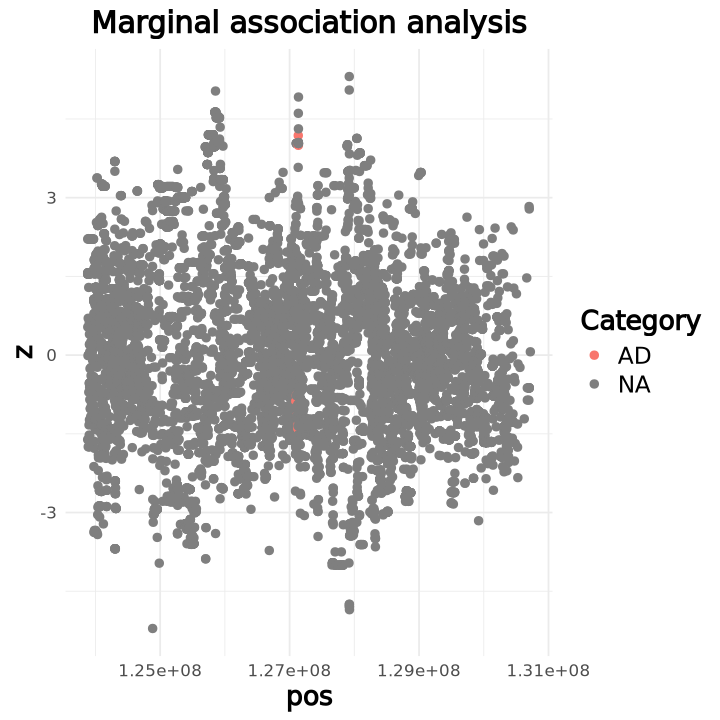

In [40]:
options(repr.plot.width=6, repr.plot.height=6)
ggplot(MiGA_z, aes(x = pos, y = z, color = color)) + 
      geom_point(size = 2) +
labs(title = "Marginal association analysis",color = "Category") +
  theme_minimal() +
  theme(text = element_text(size = 14), # Changes overall text size
        axis.title = element_text(size = 16, face = "bold"),# Increase axis title size
        legend.title = element_text(size = 16, face = "bold"),
        legend.text = element_text(size = 14),
        axis.text = element_text(size = 10),   # Increase general axis text size
        plot.title = element_text(face = "bold", hjust = 0.5,size = 18)) 

In [41]:
MiGA_z <- (marginal_res[[1]]$MiGA_THA_eQTL$sumstats$betahat)/(marginal_res[[1]]$MiGA_THA_eQTL$sumstats$sebetahat)

In [42]:
MiGA_z <- data.frame(variant_id = marginal_res[[1]]$MiGA_THA_eQTL$variant_names, 
                     z = MiGA_z, 
                     beta = marginal_res[[1]]$MiGA_THA_eQTL$sumstats$betahat) %>% 
            mutate(pos =str_split(variant_id, ':', simplify = T)[,2] %>% as.numeric,
                  color = ifelse(variant_id %in% fla_tb_ad_cs$variant_ID, 'AD', 
                                ifelse(variant_id %in% BIN1_MiGA_df$variant_ID, 'MiGA_finemapping', 
                                      ifelse(variant_id %in% (BIN1_notMiGA_df %>% filter(str_detect(context, 'Mic_')) %>% pull(variant_ID)), 'Mic_fmp', NA)))) %>% arrange(pos)

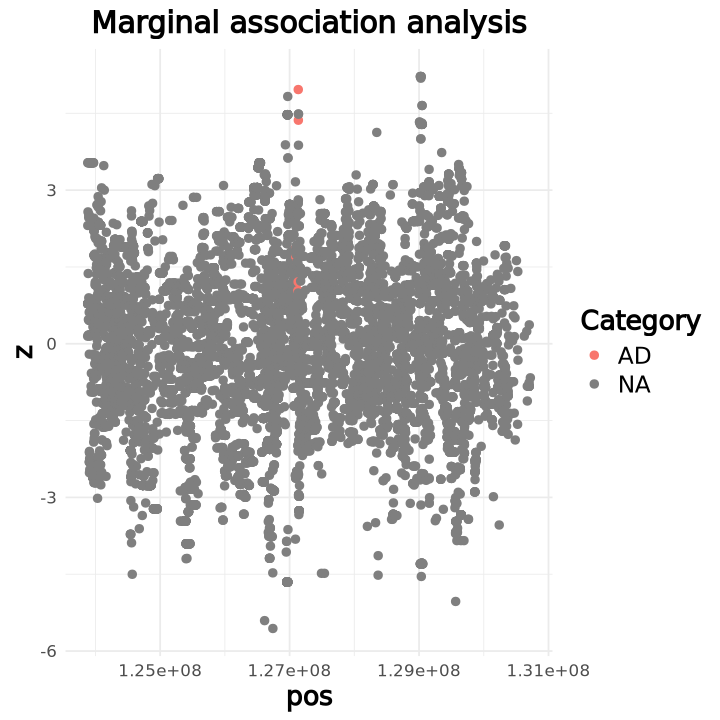

In [43]:
options(repr.plot.width=6, repr.plot.height=6)
ggplot(MiGA_z, aes(x = pos, y = z, color = color)) + 
      geom_point(size = 2) +
labs(title = "Marginal association analysis", color = "Category") +
  theme_minimal() +
  theme(text = element_text(size = 14), # Changes overall text size
        axis.title = element_text(size = 16, face = "bold"),# Increase axis title size
        legend.title = element_text(size = 16, face = "bold"),
        legend.text = element_text(size = 14),
        axis.text = element_text(size = 10),   # Increase general axis text size
        plot.title = element_text(face = "bold", hjust = 0.5,size = 18)) 